# Graduate Admission Prediction — Comparative Regression Study

**Dataset:** Graduate Admissions dataset (400 records, 7 features + 1 target)  
**Source:** [Kaggle — Graduate Admission](https://www.kaggle.com/datasets/mohansacharya/graduate-admissions)  
**Task:** Predict `Chance of Admit` (0–1) from GRE Score, TOEFL Score, University Rating, SOP, LOR, CGPA, and Research experience.

**Pipeline:**
1. Data Loading & EDA
2. Preprocessing (column cleanup, scaling — no data leakage)
3. Model Training & Cross-Validation (4 models)
4. Evaluation (MAE, RMSE, R-squared)
5. Actual vs Predicted + Residual Analysis
6. Feature Importance
7. Results Summary

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style='whitegrid', palette='Set2')
RANDOM_STATE = 42
print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & EDA

In [4]:
df = pd.read_csv('data/Admission_Predict.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (400, 9)


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [5]:
# Clean column names — strip trailing spaces, drop Serial No.
df.columns = df.columns.str.strip()
if 'Serial No.' in df.columns:
    df = df.drop('Serial No.', axis=1)

# Rename for clarity
df = df.rename(columns={'Chance of Admit': 'Chance_of_Admit',
                         'University Rating': 'Univ_Rating'})

print('Cleaned columns:', list(df.columns))
print(f'Missing values: {df.isnull().sum().sum()}')

Cleaned columns: ['GRE Score', 'TOEFL Score', 'Univ_Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance_of_Admit']
Missing values: 0


In [6]:
df.describe().round(3)

,GRE Score,TOEFL Score,Univ_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
count,400.000,400.00,400.000,400.000,400.000,400.000,400.000,400.000
mean,316.808,107.41,3.088,3.400,3.452,8.599,0.548,0.724
std,11.474,6.07,1.144,1.007,0.898,0.596,0.498,0.143
min,290.000,92.00,1.000,1.000,1.000,6.800,0.000,0.340
25%,308.000,103.00,2.000,2.500,3.000,8.170,0.000,0.640
50%,317.000,107.00,3.000,3.500,3.500,8.610,1.000,0.730
75%,325.000,112.00,4.000,4.000,4.000,9.062,1.000,0.830
max,340.000,120.00,5.000,5.000,5.000,9.920,1.000,0.970


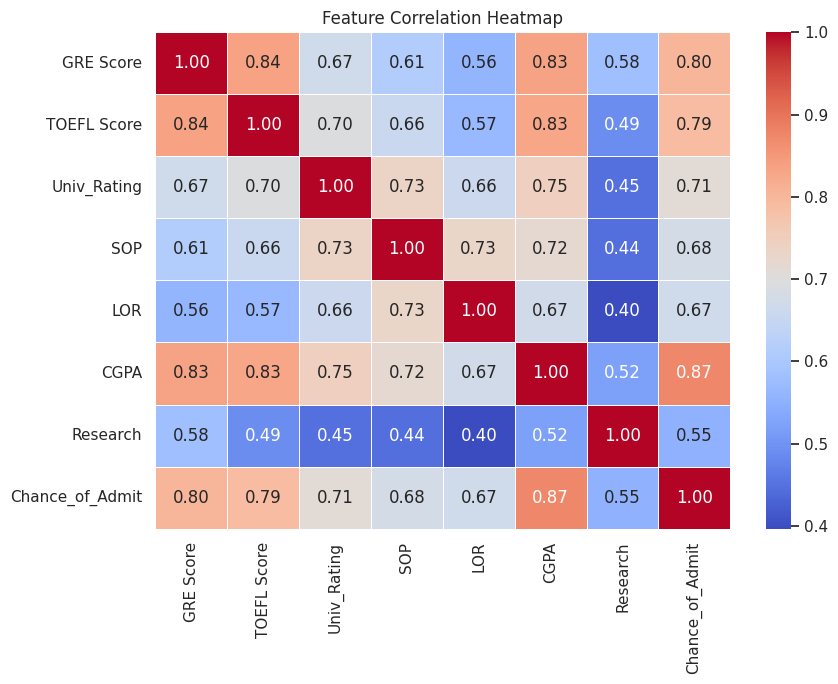

In [7]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

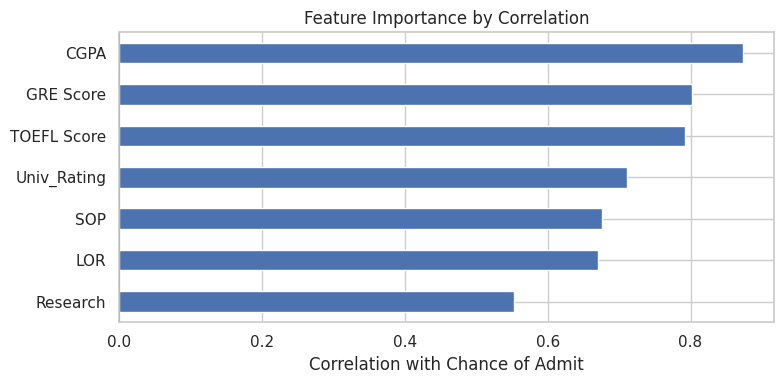

In [8]:
# Correlation with target — sorted bar
target_corr = corr['Chance_of_Admit'].drop('Chance_of_Admit').sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
target_corr.plot(kind='barh', color=['#4C72B0' if v > 0 else '#d62728' for v in target_corr], ax=ax)
ax.set_xlabel('Correlation with Chance of Admit')
ax.set_title('Feature Importance by Correlation')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

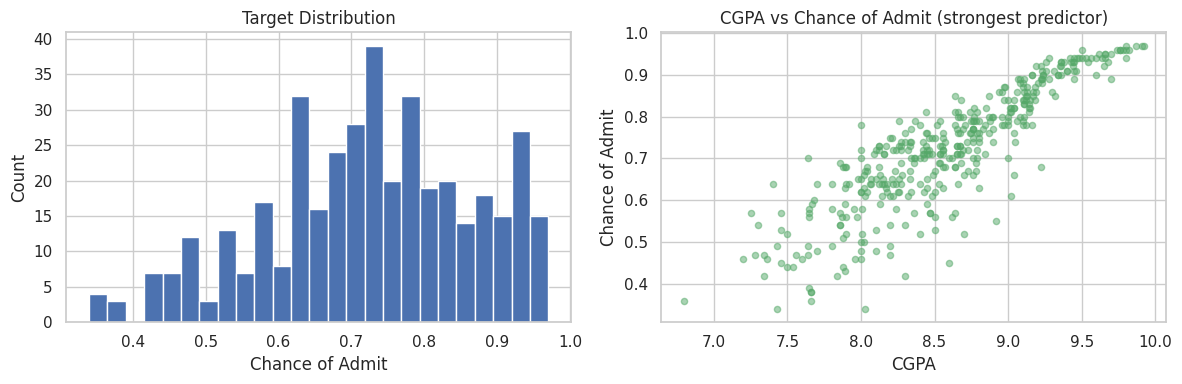

In [9]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Chance_of_Admit'], bins=25, color='#4C72B0', edgecolor='white')
axes[0].set_xlabel('Chance of Admit')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution')

# Top predictor scatter
axes[1].scatter(df['CGPA'], df['Chance_of_Admit'], alpha=0.5, s=20, color='#55A868')
axes[1].set_xlabel('CGPA')
axes[1].set_ylabel('Chance of Admit')
axes[1].set_title('CGPA vs Chance of Admit (strongest predictor)')

plt.tight_layout()
plt.show()

**EDA Takeaways:**
- `CGPA`, `GRE Score`, and `TOEFL Score` have the highest correlation with admission chance.
- `Research` is binary (0/1) — it acts as a categorical indicator.
- Target is roughly normally distributed with slight left skew — no extreme outliers.
- Features are positively correlated with each other and the target — multicollinearity exists, which Ridge regression handles well.

## 2. Preprocessing

**Critical:** The scaler is fit **only** on the training set. The test set is transformed using the training set's statistics — never `fit_transform` on test data.

In [10]:
# Separate features and target
X = df.drop('Chance_of_Admit', axis=1)
y = df['Chance_of_Admit']

# 80/20 stratified-ish split (random_state for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

# MinMaxScaler — fit on train ONLY
scaler = MinMaxScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test),       # transform only — NO fit
    columns=X_test.columns, index=X_test.index
)

print(f'Scaled train range: [{X_train_sc.min().min():.2f}, {X_train_sc.max().max():.2f}]')

Train: 320 | Test: 80
Scaled train range: [0.00, 1.00]


## 3. Model Training & Cross-Validation

In [11]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'SVR (RBF)':         SVR(kernel='rbf', C=1.0),
}

cv_results = {}
trained_models = {}

print(f'{"Model":<22} {"CV MAE (mean)":>14} {"CV MAE (±std)":>14}')
print('-' * 52)

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    trained_models[name] = model

    scores = cross_val_score(
        model, X_train_sc, y_train,
        cv=5, scoring='neg_mean_absolute_error'
    )
    cv_mae = -scores
    cv_results[name] = cv_mae
    print(f'{name:<22} {cv_mae.mean():>14.4f} {cv_mae.std():>14.4f}')

Model                   CV MAE (mean)  CV MAE (±std)
----------------------------------------------------
Linear Regression              0.0451         0.0049
Ridge (alpha=1.0)              0.0455         0.0047
Random Forest                  0.0507         0.0049
SVR (RBF)                      0.0648         0.0033


/tmp/ipykernel_315/534249664.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(cv_results.values(), labels=cv_results.keys())


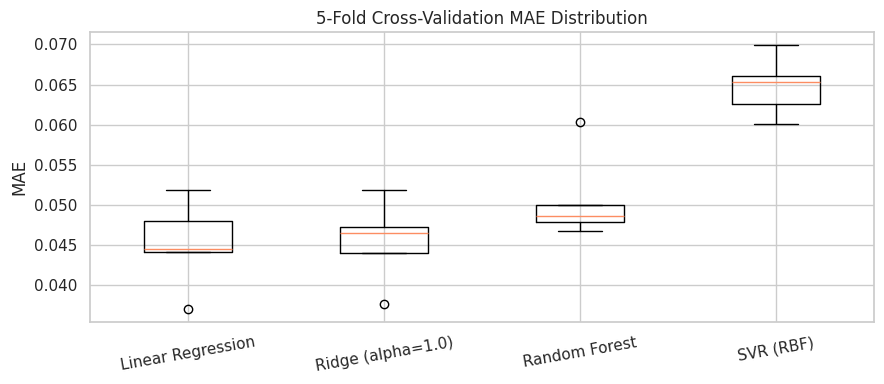

In [12]:
# CV MAE box plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(cv_results.values(), labels=cv_results.keys())
ax.set_ylabel('MAE')
ax.set_title('5-Fold Cross-Validation MAE Distribution')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## 4. Evaluation on Test Set

In [13]:
eval_rows = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test_sc)
    cv_mae = cv_results[name]
    eval_rows.append({
        'Model': name,
        'CV MAE': round(cv_mae.mean(), 4),
        'Test MAE': round(mean_absolute_error(y_test, y_pred), 4),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'Test R²': round(r2_score(y_test, y_pred), 4),
    })

eval_df = pd.DataFrame(eval_rows).set_index('Model')
eval_df

,CV MAE,Test MAE,Test RMSE,Test R²
Model,,,,
Linear Regression,0.0451,0.0480,0.0679,0.8212
Ridge (alpha=1.0),0.0455,0.0488,0.0695,0.8129
Random Forest,0.0507,0.0497,0.0704,0.8081
SVR (RBF),0.0648,0.0665,0.0804,0.7496


## 5. Actual vs Predicted + Residual Analysis

Best model: Linear Regression (R² = 0.8212)


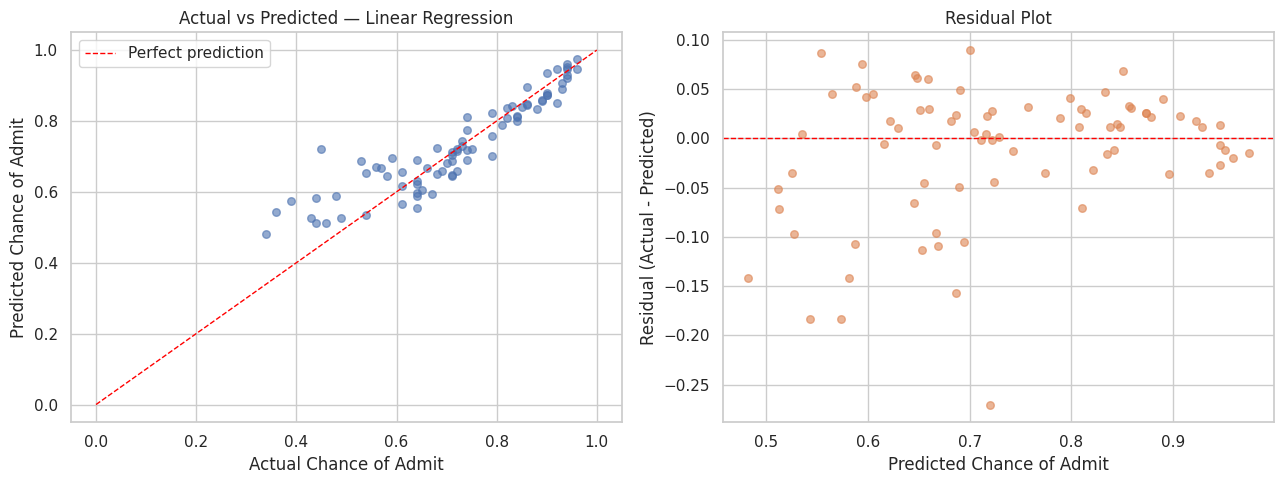

In [14]:
# Best model (by test R²)
best_name = eval_df['Test R²'].idxmax()
best_model = trained_models[best_name]
y_pred_best = best_model.predict(X_test_sc)
print(f'Best model: {best_name} (R² = {eval_df.loc[best_name, "Test R²"]})')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.6, s=30, color='#4C72B0')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('Actual Chance of Admit')
axes[0].set_ylabel('Predicted Chance of Admit')
axes[0].set_title(f'Actual vs Predicted — {best_name}')
axes[0].legend()

# Residual plot
residuals = y_test.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.6, s=30, color='#DD8452')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Chance of Admit')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

Mean residual: -0.0123 (should be near 0)
Std residual:  0.0668


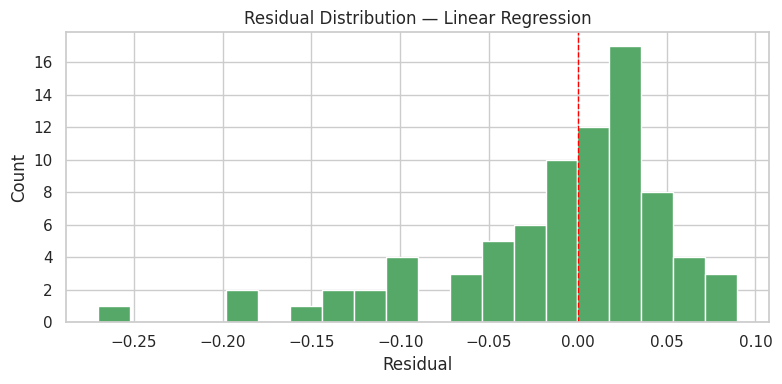

In [15]:
# Residual distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=20, color='#55A868', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Residual')
ax.set_ylabel('Count')
ax.set_title(f'Residual Distribution — {best_name}')
print(f'Mean residual: {residuals.mean():.4f} (should be near 0)')
print(f'Std residual:  {residuals.std():.4f}')
plt.tight_layout()
plt.show()

## 6. Feature Importance

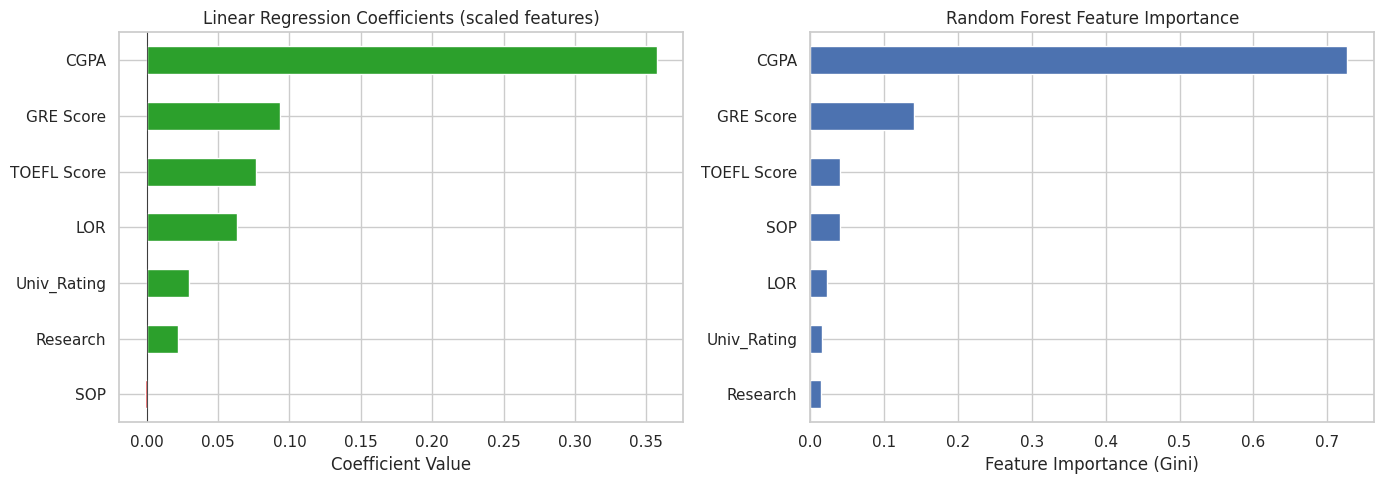

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression coefficients
lr = trained_models['Linear Regression']
coefs = pd.Series(lr.coef_, index=X_train.columns).sort_values()
coefs.plot(kind='barh', color=['#d62728' if v < 0 else '#2ca02c' for v in coefs], ax=axes[0])
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Linear Regression Coefficients (scaled features)')
axes[0].axvline(0, color='black', linewidth=0.5)

# Random Forest feature importance
rf = trained_models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()
importances.plot(kind='barh', color='#4C72B0', ax=axes[1])
axes[1].set_xlabel('Feature Importance (Gini)')
axes[1].set_title('Random Forest Feature Importance')

plt.tight_layout()
plt.show()

## 7. Results Summary

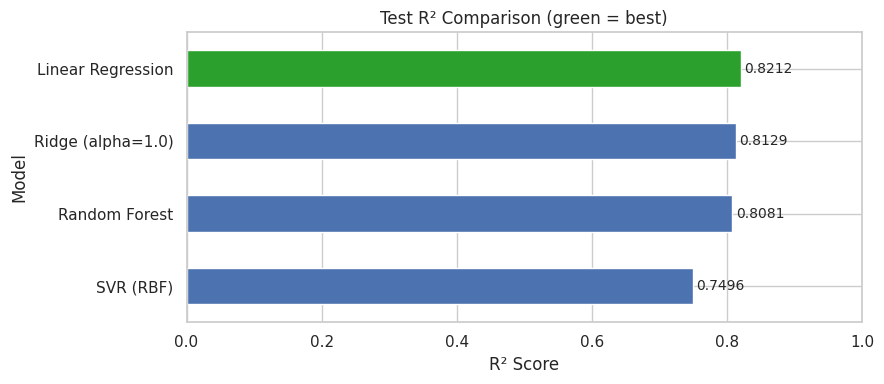


Final results:


,CV MAE,Test MAE,Test RMSE,Test R²
Model,,,,
Linear Regression,0.0451,0.0480,0.0679,0.8212
Ridge (alpha=1.0),0.0455,0.0488,0.0695,0.8129
Random Forest,0.0507,0.0497,0.0704,0.8081
SVR (RBF),0.0648,0.0665,0.0804,0.7496


In [17]:
# Visual comparison — Test R² per model
fig, ax = plt.subplots(figsize=(9, 4))
r2_vals = eval_df['Test R²'].sort_values()
colors = ['#2ca02c' if v == r2_vals.max() else '#4C72B0' for v in r2_vals]
r2_vals.plot(kind='barh', color=colors, ax=ax)
for i, v in enumerate(r2_vals):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)
ax.set_xlabel('R² Score')
ax.set_title('Test R² Comparison (green = best)')
ax.set_xlim(0, 1.0)
plt.tight_layout()
plt.show()

print('\nFinal results:')
eval_df

## Conclusions

- **CGPA** is the strongest predictor of admission chance across all models — both Linear Regression coefficients and Random Forest feature importance agree.
- **Linear Regression and Ridge** perform competitively — the relationship between features and admission chance is largely linear. Ridge's regularization offers stability against multicollinearity without significant accuracy loss.
- **Random Forest** captures non-linear patterns but doesn't dramatically outperform linear models on this dataset, suggesting the underlying relationship is approximately linear.
- **Residuals are centered around zero** with no systematic bias — the model doesn't consistently over- or under-predict.
- **Proper scaling protocol** (fit on train, transform on test) prevents data leakage — a common mistake in many implementations of this dataset.